### Clone our [GitHub repository](https://github.com/zradj/roman-coins-deep-learning.git)

In [ ]:
!git clone https://github.com/zradj/roman-coins-deep-learning.git

fatal: destination path 'roman-coins-deep-learning' already exists and is not an empty directory.


### The dataset can be downloaded from [authors' Google Drive](https://drive.google.com/file/d/1Bxcoesctd4xKvXMdgbLTCLjQkC7peQPY/view). The size of the dataset is approximately 8.7GB.

### Our pretrained model can be downloaded from [Google Drive](https://drive.google.com/file/d/1vrWpiAQRsmYf2ocJFX3Ee0mM354MsuaA/view?usp=sharing). The size of the model is approximately 99.6MB.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls drive/MyDrive/SaveGames/Data/

CoinsDataset.zip  RRC-60.zip


## Unzip CoinsDataset.zip

### Subtask:
Extract the contents of `CoinsDataset.zip` from its current location into a designated directory.


In [ ]:
import os
import zipfile

# Define the paths
zip_file_path = 'drive/MyDrive/SaveGames/Data/CoinsDataset.zip'
extraction_path = '.'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"'{zip_file_path}' unzipped to '{extraction_path}' successfully.")

'drive/MyDrive/SaveGames/Data/CoinsDataset.zip' unzipped to '.' successfully.


# Exploratory Data Analysis (EDA)

In this project, we will use the `Roman Republican Coin Dataset`, specifically its _main dataset_ called `RRCD-Main`, that consists of approximately 18,000 different coin images from the Roman Republican era. The images are labeled with 100 different classes that represent different reverse motifs, such as "quadriga, griffin, elephant, and many more". More details on the dataset can be found in the paper where it was introduced [(Anwar et al., 2020)](https://arxiv.org/pdf/1908.09428).

## Structure

The dataset consists of the main folder, `images`, and three auxiliary files: `images.txt`, `labels.txt`, and `split.txt`. The main folder contains the image files distributed into numbered folders based on their label classes.

`images.txt` maps the image names to a sequence of integers starting from 1.

`labels.txt` maps each image number to the corresponding label.

`split.txt` splits the dataset into train and test sets.


In [ ]:
import os
from IPython.display import display, HTML

def build_tree(root, max_files=5, indent='', is_last=True, is_first=True):
    lines = []
    name = os.path.basename(root) or root
    connector = '└── ' if is_last else '├── '
    lines.append(indent + (connector if indent else '') + f'<b>{name}/</b>')
    indent += '    ' if is_last else '│   '

    try:
        entries = sorted(os.listdir(root))
    except PermissionError:
        lines.append(indent + '└── [permission denied]')
        return lines

    dirs  = [e for e in entries if os.path.isdir(os.path.join(root, e))]
    files = [e for e in entries if os.path.isfile(os.path.join(root, e))]

    for i, d in enumerate(dirs):
        is_last_entry = (i == len(dirs) - 1) and not files
        lines += build_tree(os.path.join(root, d), max_files, indent, is_last_entry, is_first=False)

    if len(files) <= max_files or is_first:
        for i, f in enumerate(files):
            connector = '└── ' if i == len(files) - 1 else '├── '
            lines.append(indent + connector + f)
    else:
        for f in files[:max_files]:
            lines.append(indent + '├── ' + f)
        lines.append(indent + f'└── <i>... ({len(files) - max_files:,} files)</i>')

    return lines


lines = build_tree('CoinsDataset/', max_files=0)

display(HTML(f"""
<pre style="font-size: 11px; line-height: 1.2; font-family: monospace;">
{'<br>'.join(lines)}
</pre>
"""))

## Dimensions

The dimensions of images vary from 99x99 to 2260x2260 pixels (all images are in the shape of a square or are very close to it). Thus, we had to resize the images to provide a uniform image format for the model. We mainly considered three options: 64x64 (minimize the computation cost and not magnify any images), 128x128 (balance the computation cost and magnify about 50 images), and 256x256 (maximize the computation cost and magnify about 1000 images). We decided to continue with the former (64x64) since it preserves the coin features necessary for classification well, while significantly reducing the computational costs. In Phase 2 of our project, we are planning to compare the model's performance among those 3 options

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import os

base_dataset_path = 'CoinsDataset/'
images_file = os.path.join(base_dataset_path, 'images.txt')
images_dir  = os.path.join(base_dataset_path, 'images/')

images_df = pd.read_csv(images_file, sep=' ', header=None, names=['id', 'path'])

sizes = []
for _, row in images_df.iterrows():
    full_image_path = os.path.join(images_dir, row['path'])
    try:
        img = mpimg.imread(full_image_path)
        sizes.append(img.shape[0])
    except Exception as e:
        print(f"Skipping {full_image_path}: {e}")

sizes = np.array(sizes)
mean_size   = sizes.mean()
median_size = np.median(sizes)
p25, p75    = np.percentile(sizes, [25, 75])

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(sizes, bins=50, color='steelblue', edgecolor='white', linewidth=0.5)

y_max = ax.get_ylim()[1]

# Stagger label heights to prevent overlap
stats = [
    (p25,         f'P25 ({p25:.0f}px)',         'gray',   0.75),
    (median_size, f'Median ({median_size:.0f}px)', 'orange', 0.90),
    (mean_size,   f'Mean ({mean_size:.0f}px)',   'tomato', 0.82),
    (p75,         f'P75 ({p75:.0f}px)',           'gray',   0.68),
]

for val, label, color, y_frac in stats:
    ax.axvline(val, color=color, linestyle='--', linewidth=1.4)
    ax.text(
        val + 8, y_max * y_frac, label,
        ha='left', va='center', fontsize=8.5,
        color=color, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none')
    )

# Dense ticks: every 50px up to 500, then every 250px beyond
fine_ticks   = np.arange(0, 501, 50)
coarse_ticks = np.arange(750, sizes.max() + 250, 250)
all_ticks    = np.unique(np.concatenate([fine_ticks, coarse_ticks]))
ax.set_xticks(all_ticks)
ax.tick_params(axis='x', rotation=45, labelsize=8)

ax.set_title(
    f'Image Size Distribution   '
    f'(n = {len(sizes):,}  |  unique sizes = {len(set(sizes)):,}  |  range = {sizes.min()}–{sizes.max()} px)',
    fontsize=12
)
ax.set_xlabel('Size (px)')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3, linewidth=0.5)
plt.tight_layout()
plt.show()

## Demonstration

The following code demonstrates five sample images from the dataset along with their labels:

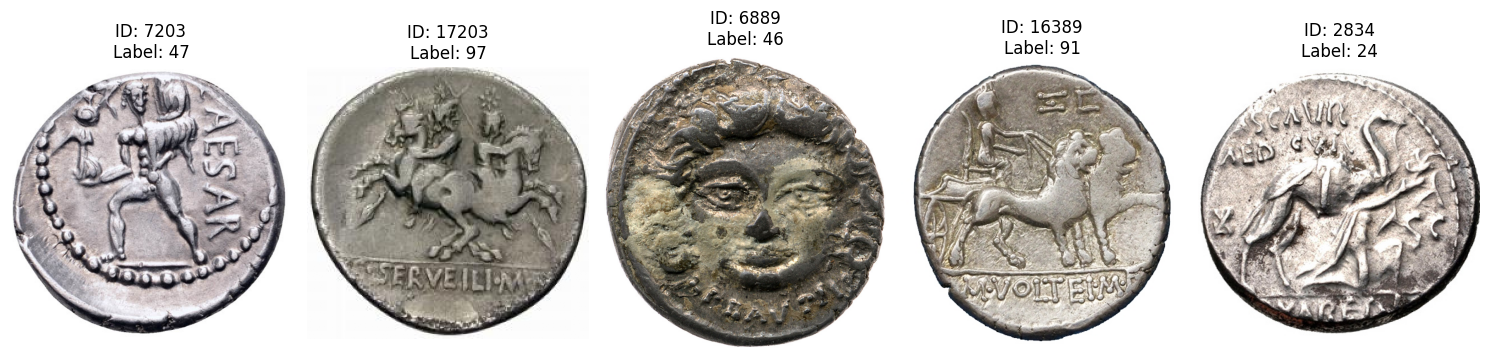

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Define paths
base_dataset_path = 'CoinsDataset/'
images_file = os.path.join(base_dataset_path, 'images.txt')
labels_file = os.path.join(base_dataset_path, 'labels.txt')
images_dir = os.path.join(base_dataset_path, 'images/')

# Load images.txt into a DataFrame
images_df = pd.read_csv(images_file, sep=' ', header=None, names=['id', 'path'])

# Load labels.txt into a DataFrame
labels_df = pd.read_csv(labels_file, sep=' ', header=None, names=['id', 'label'])

# Merge the two dataframes to get image paths and their labels
data_df = pd.merge(images_df, labels_df, on='id')

# Display a few sample images with their labels
plt.figure(figsize=(15, 10))
for i in range(5):
    # Get a random sample
    sample = data_df.sample(1).iloc[0]
    image_id = sample['id']
    image_path_relative = sample['path']
    label = sample['label']

    # Construct the full image path (assuming images are in subdirectories named after their category)
    # The 'path' in images.txt is like '1/004076.png', where '1' is the label/category ID.
    # So, the full path is images_dir + image_path_relative
    full_image_path = os.path.join(images_dir, image_path_relative)

    plt.subplot(1, 5, i + 1)
    try:
        img = mpimg.imread(full_image_path)
        plt.imshow(img)
        plt.title(f"ID: {image_id}\nLabel: {label}")
        plt.axis('off')
    except FileNotFoundError:
        print(f"Warning: Image not found at {full_image_path}")
        plt.title(f"Image not found\nID: {image_id}")
        plt.axis('off')
    except Exception as e:
        print(f"An error occurred while loading image {full_image_path}: {e}")
        plt.title(f"Error loading\nID: {image_id}")
        plt.axis('off')

plt.tight_layout()
plt.show()


## Create Stratified Train/Test Split

Generate the split.txt file with **stratified sampling** to ensure equal class distribution across train and test sets. Each coin class (label) will have the same proportion in both training and testing splits.

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict

def create_stratified_train_test_split(base_path='CoinsDataset', test_percentage=0.6, random_seed=42):
    """
    Create a stratified train/test split file for the CoinsDataset
    Ensures equal label distribution across train and test sets

    Args:
        base_path: Path to the CoinsDataset directory
        test_percentage: Percentage of data to use for testing (0.0 to 1.0)
        random_seed: Random seed for reproducible splits

    Returns:
        tuple: (train_count, test_count, class_distribution) - number of samples and class info
    """
    # Set random seed for reproducibility
    np.random.seed(random_seed)

    # Read the images.txt and labels.txt files
    images_file = Path(base_path) / 'images.txt'
    labels_file = Path(base_path) / 'labels.txt'

    if not images_file.exists():
        raise FileNotFoundError(f"Images file not found: {images_file}")
    if not labels_file.exists():
        raise FileNotFoundError(f"Labels file not found: {labels_file}")

    # Load data
    images_df = pd.read_csv(images_file, sep=' ', header=None, names=['id', 'path'])
    labels_df = pd.read_csv(labels_file, sep=' ', header=None, names=['id', 'label'])

    # Merge images and labels
    data_df = pd.merge(images_df, labels_df, on='id')

    print(f"📊 Total images found: {len(data_df)}")
    print(f"🏷️  Number of unique classes: {data_df['label'].nunique()}")
    print(f"📈 Label range: {data_df['label'].min()} - {data_df['label'].max()}")

    # Group by labels for stratified sampling
    class_groups = data_df.groupby('label')

    print(f"\n📋 Class distribution:")
    class_counts = data_df['label'].value_counts().sort_index()
    for label, count in class_counts.items():
        print(f"   Class {label}: {count} images")

    # Perform stratified split
    train_data = []
    test_data = []
    class_distribution = {}

    for label, group in class_groups:
        # Get all image IDs for this class
        class_ids = group['id'].values
        n_class = len(class_ids)

        # Calculate split for this class
        n_test_class = int(n_class * test_percentage)
        n_train_class = n_class - n_test_class

        # Randomly shuffle IDs for this class
        shuffled_class_ids = np.random.permutation(class_ids)

        # Split into train and test
        train_ids = shuffled_class_ids[:n_train_class]
        test_ids = shuffled_class_ids[n_train_class:]

        # Add to respective lists
        for img_id in train_ids:
            train_data.append([img_id, 1])  # 1 for train
        for img_id in test_ids:
            test_data.append([img_id, 0])  # 0 for test

        # Store class distribution info
        class_distribution[label] = {
            'total': n_class,
            'train': n_train_class,
            'test': n_test_class,
            'train_pct': (n_train_class / n_class) * 100,
            'test_pct': (n_test_class / n_class) * 100
        }

    # Combine train and test data
    all_split_data = train_data + test_data

    # Sort by image ID to maintain consistent ordering
    all_split_data.sort(key=lambda x: x[0])

    # Create DataFrame and save to split.txt
    split_df = pd.DataFrame(all_split_data, columns=['id', 'split'])
    split_file = Path(base_path) / 'split.txt'

    # Save without header, space-separated
    split_df.to_csv(split_file, sep=' ', header=False, index=False)

    print(f"\n✅ Stratified split file created: {split_file}")
    print(f"📄 Format: 'image_id split_value' (1=train, 0=test)")

    # Verify the split
    train_count = (split_df['split'] == 1).sum()
    test_count = (split_df['split'] == 0).sum()

    print(f"\n🔍 Overall split verification:")
    print(f"   - Total train samples: {train_count} ({(train_count/(train_count+test_count))*100:.1f}%)")
    print(f"   - Total test samples: {test_count} ({(test_count/(train_count+test_count))*100:.1f}%)")

    # Verify stratification by checking a few classes
    print(f"\n🎯 Stratification verification (sample classes):")
    sample_classes = sorted(class_distribution.keys())[:5]  # Show first 5 classes
    for label in sample_classes:
        info = class_distribution[label]
        print(f"   Class {label}: {info['train']} train ({info['train_pct']:.1f}%) | {info['test']} test ({info['test_pct']:.1f}%)")

    if len(class_distribution) > 5:
        print(f"   ... and {len(class_distribution) - 5} more classes with similar distribution")

    return train_count, test_count, class_distribution

# Create stratified split with equal class distribution
train_count, test_count, class_dist = create_stratified_train_test_split(
    base_path='CoinsDataset',
    test_percentage=0.2,
    random_seed=42        # For reproducible results
)

print(f"\n🎉 Stratified split creation completed!")
print(f"   📈 Training set: {train_count} images")
print(f"   📊 Test set: {test_count} images")
print(f"   ⚖️  Equal class distribution maintained across both sets")

# Start training KAN-Mixer

## DataLoader Hyperparameters

---

`batch_size = 128` - Batch size for training/testing

**Explanation:** Manageable batch size for GPU memory on H100 GPU used on Colab Pro. Can be decreased if other parameters affecting the GPU usage are increased.

---

`num_workers = 4` - Number of worker processes for data loading

**Explanation:** Set to 4 for multiprocessing and as a result faster data loading

---

`shuffle_train = True` - Shuffle training data

**Explanation:** Randomizes training order each epoch to:
- Prevent overfitting to data order
- Improve generalization
- Ensure balanced mini-batches

---

`shuffle_test = False` - Don't shuffle test data

**Explanation:** Keep test data in consistent order for:
- Reproducible evaluation results
- Easier debugging and analysis
- Fair comparison across runs

---



In [ ]:
import sys
import os
from pathlib import Path

# Add the KAN-Mixer directory to Python path
kan_mixer_path = Path('roman-coins-deep-learning/KAN_Mixer').resolve()
if str(kan_mixer_path) not in sys.path:
    sys.path.insert(0, str(kan_mixer_path))

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

# Import the KAN-Mixer model and config from the roman-coins-deep-learning repository
try:
    from model import KANMixer
    from config import get_config, get_weights_file_path
    print("✅ Successfully imported KAN-Mixer modules")
except ImportError as e:
    print(f"❌ Import error: {e}")
    print("Available files in KAN_Mixer directory:")
    for f in os.listdir('roman-coins-deep-learning/KAN_Mixer'):
        print(f"  - {f}")
    raise

class CoinsDataset(Dataset):
    def __init__(self, base_path='CoinsDataset', split='train', transform=None):
        """
        Custom dataset for Roman coins
        Args:
            base_path: Path to the CoinsDataset directory
            split: 'train' or 'test'
            transform: Image transformations
        """
        self.base_path = base_path
        self.transform = transform

        # Load the data files
        images_df = pd.read_csv(os.path.join(base_path, 'images.txt'), sep=' ', header=None, names=['id', 'path'])
        labels_df = pd.read_csv(os.path.join(base_path, 'labels.txt'), sep=' ', header=None, names=['id', 'label'])
        split_df = pd.read_csv(os.path.join(base_path, 'split.txt'), sep=' ', header=None, names=['id', 'split'])

        # Merge the dataframes
        self.data = pd.merge(images_df, labels_df, on='id')
        self.data = pd.merge(self.data, split_df, on='id')

        # Filter by split (1 for train, 0 for test)
        split_value = 1 if split == 'train' else 0
        self.data = self.data[self.data['split'] == split_value].reset_index(drop=True)

        # Convert labels to 0-based indexing (original labels are 1-100, we need 0-99)
        self.data['label'] = self.data['label'] - 1

        print(f"📊 Loaded {len(self.data)} samples for {split} split")
        print(f"🎯 Number of classes: {len(self.data['label'].unique())}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image_path = os.path.join(self.base_path, 'images', row['path'])
        label = int(row['label'])

        # Load image
        image = Image.open(image_path).convert('RGB')  # Convert to RGB for consistency

        if self.transform:
            image = self.transform(image)

        return image, label

# Define transforms for coin images
transform = transforms.Compose([
    transforms.Resize((64, 64)),  # Resize coins to 64x64
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization for RGB
])

print("🚀 Creating datasets...")
# Create datasets
train_dataset = CoinsDataset(split='train', transform=transform)
test_dataset = CoinsDataset(split='test', transform=transform)

# DataLoader hyperparameters (explained in the Markdown cell above)
batch_size = 128
num_workers = 4
shuffle_train = True
shuffle_test = False

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=shuffle_train,
    num_workers=num_workers
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=shuffle_test,
    num_workers=num_workers
)

print(f"✅ Train loader: {len(train_loader)} batches")
print(f"✅ Test loader: {len(test_loader)} batches")

✅ Successfully imported KAN-Mixer modules
🚀 Creating datasets...
📊 Loaded 14075 samples for train split
🎯 Number of classes: 100
📊 Loaded 3472 samples for test split
🎯 Number of classes: 100
✅ Train loader: 110 batches
✅ Test loader: 28 batches


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## Hyperparameters for `KAN-Mixer`

---

### Input Configuration

---

`"in_channels": 3` - RGB images (3 color channels)

**Explanation:** Coins have subtle color variations (patina, metal types) that help distinguish between different coin types and periods.

---

`"image_size": 64` - Resized to 64x64 pixels

**Explanation:** Balances detail preservation with computational efficiency. 64x64 captures essential coin features (inscriptions, portraits, symbols) while keeping memory usage manageable for the 100-class problem.

---

### Model Architecture

---

`"num_classes": 100` - 100 different coin types in the dataset

**Explanation:** Fixed by dataset - each class represents a unique Roman coin type with distinct historical and visual characteristics.

---

`"channel_dim": 256` - Increased capacity for complex coin features

**Explanation:** Coins have intricate details (text, portraits, symbols). 256 dimensions provide sufficient capacity to encode fine-grained visual differences between similar coin types.

---

`"token_dim": 128` - Increased token dimension for spatial relationships

**Explanation:** Coins have spatial relationships between elements (portrait position, text layout, symbols). 128 dims capture these positional and relational features effectively.

---

`"depth": 6` - Deeper model for better feature extraction

**Explanation:** 6 layers allow hierarchical learning:
- Early layers: edges, textures, basic shapes
- Middle layers: coin elements (portraits, inscriptions)
- Output layer: complete coin type identification

---

### Training Configuration

---

`"learning_rate": 1e-3` - Lower learning rate for fine-grained classification

**Explanation:** Conservative learning rate prevents overshooting optima in the complex 100-class space. Allows model to learn subtle inter-class differences without unstable training.

---

`"batch_size": 128` - Manageable batch size for GPU memory on H100 GPU used on Colab Pro. Can be decreased if other parameters affecting the GPU usage are increased.

---

`"num_epochs": 10` - Start with 10 epochs for initial training

**Explanation:** In our case model converged after only 5 epochs so 10 epochs might be enough to check the convergence.

---

### Output Configuration

---

`"model_folder": "weights_coins"` - Directory for saving model checkpoints

---

`"model_basename": "kan_mixer_coins_"` - Prefix for model checkpoint files

---


In [ ]:
# Setup KAN-Mixer configuration for coin classification
def get_coin_config():
    """
    Configuration for KAN-Mixer model tailored for Roman coin classification
    Each hyperparameter is carefully chosen based on the characteristics of coin images
    """
    return {
        ### INPUT CONFIGURATION ###
        "in_channels": 3,
        "image_size": 64,

        ### MODEL ARCHITECTURE ###
        "num_classes": 100,
        "channel_dim": 256,
        "token_dim": 128,
        "depth": 6,

        ### TRAINING CONFIGURATION ###
        "learning_rate": 1e-3,
        "batch_size": 128,
        "num_epochs": 10,

        ### OUTPUT CONFIGURATION ###
        "model_folder": "weights_coins",
        "model_basename": "kan_mixer_coins_",
    }

In [ ]:
# Get accuracy function
def get_accuracy(loader, model, device):
    """
    Calculate classification accuracy on a dataset

    Args:
        loader: DataLoader for the dataset
        model: Trained model
        device: Computing device (CPU/GPU)

    Returns:
        float: Accuracy as a fraction (0.0 to 1.0)
    """
    num_correct = 0
    num_samples = 0
    model.eval()  # Set to evaluation mode (disables dropout, batch norm training)

    with torch.no_grad():  # Disable gradient computation for efficiency
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            _, predictions = logits.max(1)  # Get predicted class indices
            num_correct += (predictions == y).sum()
            num_samples += predictions.size(0)

    return (num_correct / num_samples).item()

# Setup device and configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

config = get_coin_config()
print(f"\n🎯 Configuration for Roman Coin Classification:")
print("=" * 50)
for key, value in config.items():
    print(f"{key:20}: {value}")

# Create model directory
os.makedirs(config["model_folder"], exist_ok=True)

# Initialize the KAN-Mixer model for coin classification
print(f"\n🏗️  Building KAN-Mixer Architecture:")
print("=" * 50)

# Calculate patch information for transparency
patch_size = 4  # 4x4 patches
num_patches = (config["image_size"] // patch_size) ** 2  # 16x16 = 256 patches
print(f"Image size: {config['image_size']}x{config['image_size']} pixels")
print(f"Patch size: {patch_size}x{patch_size} pixels")
print(f"Number of patches per image: {num_patches}")

model = KANMixer(
    in_channels=config["in_channels"],    # 3 for RGB
    image_size=config["image_size"],      # 64x64
    patch_size=patch_size,               # 4x4 patches (gives us 16x16 = 256 patches)
    num_classes=config["num_classes"],    # 100 coin classes
    embedding_dim=config["channel_dim"],  # 256
    depth=config["depth"],                # 6 layers
    token_intermediate_dim=config["token_dim"],   # 128
    channel_intermediate_dim=config["channel_dim"]  # 256
).to(device)

# Setup training components
criterion = nn.CrossEntropyLoss()  # Standard loss for multi-class classification
optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])

# Model complexity information
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n📊 Model Statistics:")
print("=" * 50)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size (approx): {total_params * 4 / (1024**2):.1f} MB")  # Assuming float32

Using device: cuda

🎯 Configuration for Roman Coin Classification:
in_channels         : 3
image_size          : 64
num_classes         : 100
channel_dim         : 256
token_dim           : 128
depth               : 6
learning_rate       : 0.001
batch_size          : 128
num_epochs          : 10
model_folder        : weights_coins
model_basename      : kan_mixer_coins_

🏗️  Building KAN-Mixer Architecture:
Image size: 64x64 pixels
Patch size: 4x4 pixels
Number of patches per image: 256

📊 Model Statistics:
Total parameters: 9,482,084
Trainable parameters: 9,482,084
Model size (approx): 36.2 MB


In [ ]:
print("Starting KAN-Mixer training on CoinsDataset...")

train_losses = []
train_accuracies = []
test_accuracies = []

Starting KAN-Mixer training on CoinsDataset...


In [ ]:
num_epochs = config["num_epochs"]

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    # Training phase
    loop = tqdm(enumerate(train_loader), total=len(train_loader), leave=False)
    for batch_idx, (images, targets) in loop:
        images = images.to(device)
        targets = targets.to(device)

        # Forward pass
        logits = model(images)
        loss = criterion(logits, targets)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Update progress bar
        loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
        loop.set_postfix(loss=loss.item())

    # Calculate average loss for the epoch
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    # Evaluate on training and test sets
    train_acc = get_accuracy(train_loader, model, device)
    test_acc = get_accuracy(test_loader, model, device)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]:")
    print(f"  Train Loss: {epoch_loss:.4f}")
    print(f"  Train Accuracy: {train_acc*100:.2f}%")
    print(f"  Test Accuracy: {test_acc*100:.2f}%")
    print("-" * 50)

    # Save model checkpoint
    model_filename = os.path.join(config["model_folder"], f"{config['model_basename']}{epoch+1}.pt")
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': epoch_loss,
        'train_acc': train_acc,
        'test_acc': test_acc,
    }, model_filename)

    print(f"Model saved to {model_filename}")

print("Training completed!")

Starting KAN-Mixer training on CoinsDataset...


Epoch [1/20]:
  Train Loss: 4.3278
  Train Accuracy: 7.70%
  Test Accuracy: 7.49%
--------------------------------------------------
Model saved to weights_coins/kan_mixer_coins_1.pt


Epoch [2/20]:
  Train Loss: 3.8644
  Train Accuracy: 23.15%
  Test Accuracy: 21.26%
--------------------------------------------------
Model saved to weights_coins/kan_mixer_coins_2.pt


Epoch [3/20]:
  Train Loss: 2.5799
  Train Accuracy: 58.50%
  Test Accuracy: 51.70%
--------------------------------------------------
Model saved to weights_coins/kan_mixer_coins_3.pt


Epoch [4/20]:
  Train Loss: 1.3986
  Train Accuracy: 79.89%
  Test Accuracy: 68.87%
--------------------------------------------------
Model saved to weights_coins/kan_mixer_coins_4.pt


...

Epoch [9/20]:
  Train Loss: 0.0621
  Train Accuracy: 99.33%
  Test Accuracy: 82.26%
--------------------------------------------------
Model saved to weights_coins/kan_mixer_coins_9.pt


Epoch [10/20]:
  Train Loss: 0.0327
  Train Accuracy: 99.35%
  Test Accuracy: 83.47%
--------------------------------------------------
Model saved to weights_coins/kan_mixer_coins_10.pt


Epoch [11/20]:
  Train Loss: 0.0229
  Train Accuracy: 99.42%
  Test Accuracy: 83.18%
--------------------------------------------------
Model saved to weights_coins/kan_mixer_coins_11.pt


Epoch [12/20]:
  Train Loss: 0.0201
  Train Accuracy: 99.42%
  Test Accuracy: 83.44%
--------------------------------------------------
Model saved to weights_coins/kan_mixer_coins_12.pt


KeyboardInterrupt: 

## Evaluation

To evaluate model's perfomance, choose the model source:

- `USE_EXISTING_MODEL`: set to False if model is loaded from checkpoint on disk. Otherwise, set to True
- `MODEL_PATH`: if `USE_EXISTING_MODEL` is set to False, set the path to checkpoint from which model will be loaded

In [ ]:
# Configuration: Choose model source
USE_EXISTING_MODEL = False # Set to False to load from file
MODEL_PATH = "./checkpoints/kan_mixer_coins_12.pt"  # Update this path when USE_EXISTING_MODEL = False

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.metrics import top_k_accuracy_score
import seaborn as sns
from collections import defaultdict
import torch
import os

def load_model_from_path(model_path, device):
    """
    Load a model from a .pt file path - handles both full models and state dict checkpoints

    Args:
        model_path (str): Path to the .pt model file
        device: torch device (cuda/cpu)

    Returns:
        torch.nn.Module: Loaded model
    """
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found at: {model_path}")

    if not model_path.endswith('.pt'):
        raise ValueError("Model file must have .pt extension")

    print(f"🔄 Loading model from: {model_path}")

    try:
        # Load the model
        checkpoint = torch.load(model_path, map_location=device)

        # Handle different save formats
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            # This is a checkpoint with state dict - we need to recreate the model architecture
            print("📋 Checkpoint contains state dict - recreating model architecture...")

            # Get model configuration (same as used during training)
            config = get_coin_config()
            patch_size = 4  # Same as during training

            # Import KANMixer
            from model import KANMixer

            # Create the model architecture
            model = KANMixer(
                in_channels=config["in_channels"],    # 3 for RGB
                image_size=config["image_size"],      # 64x64
                patch_size=patch_size,               # 4x4 patches
                num_classes=config["num_classes"],    # 100 coin classes
                embedding_dim=config["channel_dim"],  # 256
                depth=config["depth"],                # 6 layers
                token_intermediate_dim=config["token_dim"],   # 128
                channel_intermediate_dim=config["channel_dim"]  # 256
            )

            # Load the state dict
            model.load_state_dict(checkpoint['model_state_dict'])
            model.to(device)
            model.eval()

            # Print checkpoint info
            epoch = checkpoint.get('epoch', 'Unknown')
            loss = checkpoint.get('loss', 'Unknown')
            train_acc = checkpoint.get('train_acc', 'Unknown')

            print(f"✅ Model loaded successfully from checkpoint!")
            print(f"   Epoch: {epoch}")
            print(f"   Loss: {loss}")
            print(f"   Training Accuracy: {train_acc}")

            return model

        elif isinstance(checkpoint, dict):
            # If saved as state dict only (without model_state_dict key)
            print("⚠️  Model appears to be saved as state dict only.")
            print("   Please ensure you have the model architecture defined as 'model' variable")
            print("   and use model.load_state_dict() instead.")
            return None
        else:
            # Full model saved
            model = checkpoint
            model.to(device)
            model.eval()
            print("✅ Full model loaded successfully!")
            return model

    except Exception as e:
        print(f"❌ Error loading model: {str(e)}")
        print("   Make sure the model was saved properly and is compatible with current PyTorch version")
        return None


def evaluate_model_comprehensive(model, test_loader, device, num_classes=100):
    """
    Comprehensive evaluation of the model with multiple metrics

    Returns:
        dict: Dictionary containing all evaluation metrics
    """
    model.eval()
    all_predictions = []
    all_labels = []
    all_probabilities = []

    print("🔍 Computing comprehensive evaluation metrics...")

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Evaluating"):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probabilities = torch.softmax(outputs, dim=1)
            _, predictions = torch.max(outputs, 1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    # Convert to numpy arrays
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    all_probabilities = np.array(all_probabilities)

    # Calculate comprehensive metrics
    metrics = {}

    # Basic accuracy
    metrics['accuracy'] = (all_predictions == all_labels).mean()

    # F1 Scores
    metrics['f1_macro'] = f1_score(all_labels, all_predictions, average='macro')
    metrics['f1_micro'] = f1_score(all_labels, all_predictions, average='micro')
    metrics['f1_weighted'] = f1_score(all_labels, all_predictions, average='weighted')

    # Precision and Recall
    metrics['precision_macro'] = precision_score(all_labels, all_predictions, average='macro')
    metrics['precision_micro'] = precision_score(all_labels, all_predictions, average='micro')
    metrics['recall_macro'] = recall_score(all_labels, all_predictions, average='macro')
    metrics['recall_micro'] = recall_score(all_labels, all_predictions, average='micro')

    # Top-k accuracy (useful for 100-class problem)
    metrics['top_5_accuracy'] = top_k_accuracy_score(all_labels, all_probabilities, k=5)
    metrics['top_10_accuracy'] = top_k_accuracy_score(all_labels, all_probabilities, k=10)

    # Per-class metrics
    per_class_f1 = f1_score(all_labels, all_predictions, average=None)
    per_class_precision = precision_score(all_labels, all_predictions, average=None)
    per_class_recall = recall_score(all_labels, all_predictions, average=None)

    metrics['per_class_f1'] = per_class_f1
    metrics['per_class_precision'] = per_class_precision
    metrics['per_class_recall'] = per_class_recall

    # Confusion matrix
    metrics['confusion_matrix'] = confusion_matrix(all_labels, all_predictions)

    return metrics, all_predictions, all_labels, all_probabilities

# =============================================================================
# MODEL SELECTION AND LOADING
# =============================================================================



print("🚀 MODEL SELECTION")
print("=" * 50)

if USE_EXISTING_MODEL:
    print("✅ Using existing model variable")
    if 'model' not in locals() and 'model' not in globals():
        print("❌ ERROR: No existing model found!")
        print("   Please ensure 'model' variable is defined or set USE_EXISTING_MODEL = False")
        print("   and provide a valid MODEL_PATH")
        exit(1)
    else:
        print(f"   Model type: {type(model)}")
        print(f"   Model device: {next(model.parameters()).device if hasattr(model, 'parameters') else 'Unknown'}")
else:
    print(f"🔄 Loading model from file: {MODEL_PATH}")

    # Ensure device is defined
    if 'device' not in locals() and 'device' not in globals():
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"   Device not found, using: {device}")

    # Load model from file
    model = load_model_from_path(MODEL_PATH, device)

    if model is None:
        print("❌ Failed to load model from file. Exiting...")
        exit(1)

print()

# =============================================================================
# COMPREHENSIVE MODEL EVALUATION
# =============================================================================

# Comprehensive Model Evaluation
print("📊 COMPREHENSIVE MODEL EVALUATION")
print("=" * 60)

# SOLUTION: Ensure proper variable assignment from comprehensive evaluation
print("🔧 Re-running comprehensive evaluation to ensure proper variable assignment...")

# Re-run the comprehensive evaluation with proper variable assignment
final_metrics, predictions, true_labels, probabilities = evaluate_model_comprehensive(
    model, test_loader, device, num_classes=100
)

🚀 MODEL SELECTION
🔄 Loading model from file: ./checkpoints/kan_mixer_coins_12.pt
🔄 Loading model from: ./checkpoints/kan_mixer_coins_12.pt
📋 Checkpoint contains state dict - recreating model architecture...
✅ Model loaded successfully from checkpoint!
   Epoch: 11
   Loss: 0.02010602595030584
   Training Accuracy: 0.994174063205719

📊 COMPREHENSIVE MODEL EVALUATION
🔧 Re-running comprehensive evaluation to ensure proper variable assignment...
🔍 Computing comprehensive evaluation metrics...


Evaluating:   0%|          | 0/28 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Evaluating: 100%|██████████| 28/28 [03:04<00:00,  6.59s/it]


# Insights

## 1. F1 Score Comparison
Macro, Micro, and Weighted F1 scores are nearly identical (**0.818, 0.834, 0.834**). This tight clustering suggests the classes are relatively **balanced in size** — if there were heavy class imbalance, Macro and Weighted would diverge significantly. An overall F1 of ~0.83 is solid for a fine-grained visual classification task like coins.

---

## 2. Top-K Accuracy

| K | Accuracy |
|---|---|
| Top-1 | 0.834 |
| Top-5 | 0.956 |
| Top-10 | 0.976 |

The jump from Top-1 to Top-5 is **+12.2%**, meaning the correct class is frequently in the model's top candidates but not always ranked first. This suggests the model is **confusing visually similar coin types** — the right answer is "almost there" rather than completely wrong.

---

## 3. Per-Class F1 Distribution
The distribution is **strongly left-skewed** — most classes cluster between 0.8–1.0, but a long tail extends down toward 0. The macro average of **0.818** is pulled down by a handful of poorly predicted classes. The majority of classes are actually performing better than the average suggests.

---

## 4. Best & Worst Classes

- **Worst performers** *(red)*: Classes 15 and 60 are serious outlieres at \~0.05 F1 — nearly random. They are going to be discussed below.
- **Best performers** *(green)*: Classes 40, 82, 23 etc. all score **0.95–0.97**, suggesting these coin types have distinctive, consistently captured visual features.

---

## Key Takeaway
The model is **generally strong** but has a few problem classes dragging the average down. The next step would be to investigate **Class 15** and **Class 60** specifically.

✅ Variables properly assigned:
   final_metrics keys: ['accuracy', 'f1_macro', 'f1_micro', 'f1_weighted', 'precision_macro', 'precision_micro', 'recall_macro', 'recall_micro', 'top_5_accuracy', 'top_10_accuracy', 'per_class_f1', 'per_class_precision', 'per_class_recall', 'confusion_matrix']
   predictions shape: (3472,)
   true_labels shape: (3472,)
   probabilities shape: (3472, 100)
   Shapes match: True
✅ All shapes are consistent. Ready to proceed with classification report.

🎯 OVERALL PERFORMANCE METRICS:
Accuracy:           0.8344 (83.44%)
F1 Score (Macro):   0.8181
F1 Score (Micro):   0.8344
F1 Score (Weighted):0.8340
Precision (Macro):  0.8262
Recall (Macro):     0.8163
Top-5 Accuracy:     0.9556 (95.56%)
Top-10 Accuracy:    0.9755 (97.55%)


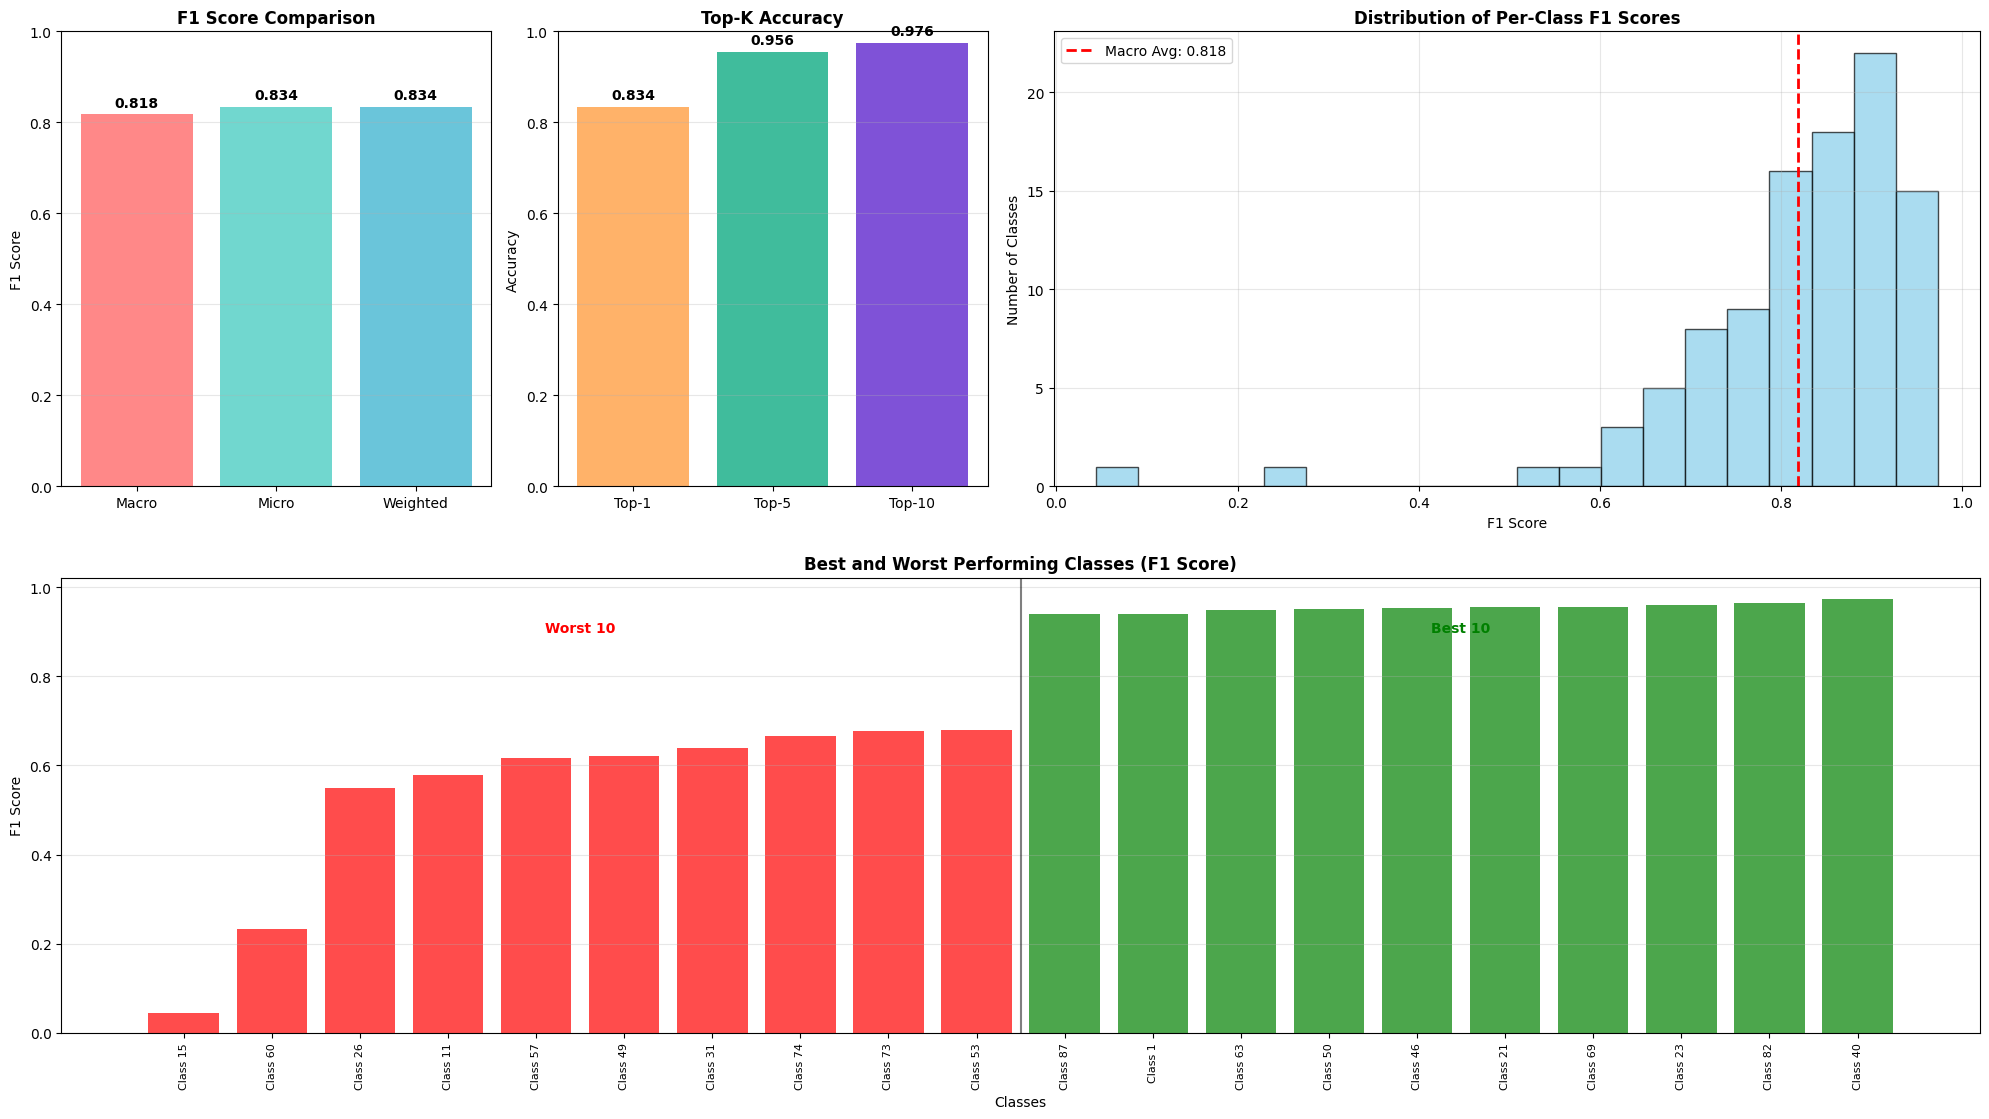

In [ ]:
print(f"✅ Variables properly assigned:")
print(f"   final_metrics keys: {list(final_metrics.keys())}")
print(f"   predictions shape: {predictions.shape}")
print(f"   true_labels shape: {true_labels.shape}")
print(f"   probabilities shape: {probabilities.shape}")
print(f"   Shapes match: {predictions.shape == true_labels.shape}")

if predictions.shape != true_labels.shape:
    print("⚠️  ERROR: Shapes still don't match after re-evaluation!")
    print("   This indicates an issue in the evaluate_model_comprehensive function.")
else:
    print("✅ All shapes are consistent. Ready to proceed with classification report.")

# Print summary metrics
print(f"\n🎯 OVERALL PERFORMANCE METRICS:")
print("=" * 40)
print(f"Accuracy:           {final_metrics['accuracy']:.4f} ({final_metrics['accuracy']*100:.2f}%)")
print(f"F1 Score (Macro):   {final_metrics['f1_macro']:.4f}")
print(f"F1 Score (Micro):   {final_metrics['f1_micro']:.4f}")
print(f"F1 Score (Weighted):{final_metrics['f1_weighted']:.4f}")
print(f"Precision (Macro):  {final_metrics['precision_macro']:.4f}")
print(f"Recall (Macro):     {final_metrics['recall_macro']:.4f}")
print(f"Top-5 Accuracy:     {final_metrics['top_5_accuracy']:.4f} ({final_metrics['top_5_accuracy']*100:.2f}%)")
print(f"Top-10 Accuracy:    {final_metrics['top_10_accuracy']:.4f} ({final_metrics['top_10_accuracy']*100:.2f}%)")

fig = plt.figure(figsize=(20, 16))

# 1. F1 Score Comparison
ax1 = plt.subplot(3, 4, 1)
f1_scores = [final_metrics['f1_macro'], final_metrics['f1_micro'], final_metrics['f1_weighted']]
f1_labels = ['Macro', 'Micro', 'Weighted']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = plt.bar(f1_labels, f1_scores, color=colors, alpha=0.8)
plt.title('F1 Score Comparison', fontsize=12, fontweight='bold')
plt.ylabel('F1 Score')
plt.ylim(0, 1)
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.3f}', ha='center', va='bottom', fontweight='bold')
plt.grid(True, axis='y', alpha=0.3)

# 2. Top-K Accuracy
ax2 = plt.subplot(3, 4, 2)
top_k_accs = [final_metrics['accuracy'], final_metrics['top_5_accuracy'], final_metrics['top_10_accuracy']]
top_k_labels = ['Top-1', 'Top-5', 'Top-10']
colors = ['#FF9F43', '#10AC84', '#5F27CD']
bars = plt.bar(top_k_labels, top_k_accs, color=colors, alpha=0.8)
plt.title('Top-K Accuracy', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for bar, acc in zip(bars, top_k_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
plt.grid(True, axis='y', alpha=0.3)

# 3. Per-Class F1 Score Distribution
ax3 = plt.subplot(3, 4, (3, 4))
plt.hist(final_metrics['per_class_f1'], bins=20, color='skyblue', alpha=0.7, edgecolor='black')
plt.axvline(final_metrics['f1_macro'], color='red', linestyle='--', linewidth=2, label=f'Macro Avg: {final_metrics["f1_macro"]:.3f}')
plt.title('Distribution of Per-Class F1 Scores', fontsize=12, fontweight='bold')
plt.xlabel('F1 Score')
plt.ylabel('Number of Classes')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Worst and Best Performing Classes
ax4 = plt.subplot(3, 4, (5, 8))
worst_classes = np.argsort(final_metrics['per_class_f1'])[:10]
best_classes = np.argsort(final_metrics['per_class_f1'])[-10:]
class_indices = np.concatenate([worst_classes, best_classes])
f1_values = final_metrics['per_class_f1'][class_indices]
class_labels = [f'Class {i+1}' for i in class_indices]
colors = ['red'] * 10 + ['green'] * 10
bars = plt.bar(range(len(class_indices)), f1_values, color=colors, alpha=0.7)
plt.title('Best and Worst Performing Classes (F1 Score)', fontsize=12, fontweight='bold')
plt.xlabel('Classes')
plt.ylabel('F1 Score')
plt.xticks(range(len(class_indices)), class_labels, rotation=90, fontsize=8)
plt.grid(True, axis='y', alpha=0.3)
plt.axvline(9.5, color='black', linestyle='-', alpha=0.5)
plt.text(4.5, 0.9, 'Worst 10', ha='center', fontweight='bold', color='red')
plt.text(14.5, 0.9, 'Best 10', ha='center', fontweight='bold', color='green')

# 5. Training Loss
if USE_EXISTING_MODEL:
    ax5 = plt.subplot(3, 4, 9)
    epochs = range(1, len(train_losses) + 1)
    plt.plot(epochs, train_losses, 'b-', linewidth=2, marker='o')
    plt.title('Training Loss', fontsize=12, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)

    # 6. Model Accuracy
    ax6 = plt.subplot(3, 4, 10)
    plt.plot(epochs, [acc*100 for acc in train_accuracies], 'b-', linewidth=2, marker='o', label='Training')
    plt.plot(epochs, [acc*100 for acc in test_accuracies], 'r-', linewidth=2, marker='s', label='Test')
    plt.title('Model Accuracy', fontsize=12, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Worst performing classes - explanation

Looking at their samples, it is hard to detect any differences even for human eye. The only difference is that **Class 15** coins are more detailed than **Class 60** maybe due to improvement of coin production tools of that time. \
And as our model got images that were resized to 64x64 pixel images, it was even harder for it to find any differences. Thus it confused them a lot. \
As mentioned previously, in Phase 2, we are planning to compare model's pefomance with different image sizes (128x128, 256x256, and existing 64x64)


Class 15



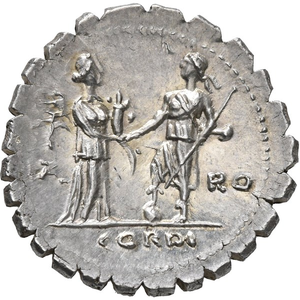


Class 60



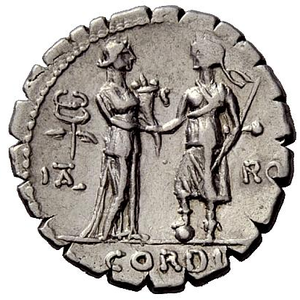

In [ ]:
from IPython.display import display
from PIL import Image

print("\nClass 15\n")
# Open an image file
img = Image.open('CoinsDataset/images/15/4458931.png')

# Define the new size as a tuple (width, height)
new_size = (300, 300)

# Resize the image and get a new Image object
resized_img = img.resize(new_size, Image.LANCZOS)
display(resized_img)
print("\nClass 60\n")
# Open an image file
img = Image.open('CoinsDataset/images/60/759149.png')
resized_img = img.resize(new_size, Image.LANCZOS)
display(resized_img)

In [ ]:
def print_confused_classes_for_label(confusion_matrix, label_index):
    import numpy as np

    pd.set_option('display.max_rows', None)
    cm = np.array(confusion_matrix)
    df=pd.DataFrame(cm)
    print(df.iloc[label_index][df.iloc[label_index]!=0])

In [ ]:
metrics = print_confused_classes_for_label(
    confusion_matrix=final_metrics['confusion_matrix'],
    label_index=14
)

14     1
48     1
59    20
Name: 14, dtype: int64


In [ ]:
metrics = print_confused_classes_for_label(
    confusion_matrix=final_metrics['confusion_matrix'],
    label_index=59
)

14    22
48     1
59     7
98     1
Name: 59, dtype: int64
